# SCICoNE RNA Implementation 

Apply data transformation in order to satisfy the SCICoNE's proportionality condition between the probability of the reads falling into a specific bin and the Copy Number State of that same region

In [3]:
#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
temporary_outpath = './'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/


In [4]:
import os

# Define paths
scdna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/cnv/'
scrna_path_ssh = '/cluster/work/bewi/members/andress/SCICoNE_lab/rna_imp/clonealign-processed-data/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19/'

scdna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/cnv/'
scrna_path_local = '/home/andress/pylabs/SCICoNE_lab/rna_imp/SA501/10X/20171026_SA501X2XB00096/outs/filtered_gene_bc_matrices/hg19/'

# Try SSH paths first
try:
    if os.path.exists(scdna_path_ssh) and os.path.exists(scrna_path_ssh):
        scdna_path = scdna_path_ssh
        scrna_path = scrna_path_ssh
    else:
        raise FileNotFoundError("SSH paths are not accessible.")
except FileNotFoundError:
    # Use local paths
    if os.path.exists(scdna_path_local) and os.path.exists(scrna_path_local):
        scdna_path = scdna_path_local
        scrna_path = scrna_path_local
    else:
        raise FileNotFoundError("Neither SSH nor local paths are accessible.")

In [ ]:
#!wget https://zenodo.org/record/2363826/files/clonealign-processed-data.tar.gz
#!tar xvzf clonealign-processed-data.tar.gz

--2025-03-26 14:29:57--  https://zenodo.org/record/2363826/files/clonealign-processed-data.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2363826/files/clonealign-processed-data.tar.gz [following]
--2025-03-26 14:29:57--  https://zenodo.org/records/2363826/files/clonealign-processed-data.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 131149037 (125M) [application/octet-stream]
Saving to: ‘clonealign-processed-data.tar.gz’

clonealign-processe 100%[===================>] 125.07M  7.30MB/s    in 15s     

2025-03-26 14:30:11 (8.61 MB/s) - ‘clonealign-processed-data.tar.gz’ saved [131149037/131149037]



In [6]:
# Read scDNA clonal CNV profiles
cnvs = pd.read_csv(f'{scdna_path}/SA501X3F.integer_copy_number.csv')
clones = pd.read_csv(f'{scdna_path}/SA501X3F_PX0286_PX0287_2-lane.clones.csv')

gr_cnvs = pyranges.from_dict(cnvs.rename(columns={'start':'Start', 'end': 'End', 'chr': 'Chromosome'}).to_dict())

/tmp/ipykernel_5216/301589122.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cnvs = pd.read_csv(f'{scdna_path}/SA501X3F.integer_copy_number.csv')


In [9]:
annot = sc.queries.biomart_annotations(
        "hsapiens",
        ["ensembl_gene_id", "start_position", "end_position", "chromosome_name"],
    ).set_index("ensembl_gene_id")
annot = annot.reset_index()
annot = annot.rename(columns={'start_position':'Start', 'end_position': 'End', 'chromosome_name': 'Chromosome'})


gr_annotations = pyranges.from_dict(annot.to_dict())

gr_annotations.head()

,ensembl_gene_id,Start,End,Chromosome
0,ENSG00000142611,3069168,3438621,1
1,ENSG00000284616,5301928,5307394,1
2,ENSG00000157911,2403964,2413797,1
3,ENSG00000260972,5492978,5494674,1
4,ENSG00000224340,10054445,10054781,1
5,ENSG00000229280,4175528,4175899,1
6,ENSG00000142655,10472288,10630758,1
7,ENSG00000232596,4571481,4594016,1


In [ ]:
gr_annotated_cnvs = gr_cnvs.join(gr_annotations).drop(like="_b").cluster().df\
            .drop_duplicates('ensembl_gene_id')\
            .reset_index(drop=True).drop(columns='Cluster')

n_genes = gr_annotated_cnvs.shape[0]


In [11]:
print(n_genes)

print(gr_annotated_cnvs.head())

78296
  Chromosome  Start     End   width  SA501X3F-00015  SA501X3F-00003  \
0          1      1  150000  150000               1               1   
1          1      1  150000  150000               1               1   
2          1      1  150000  150000               1               1   
3          1      1  150000  150000               1               1   
4          1      1  150000  150000               1               1   

   SA501X3F-00153  SA501X3F-00114  SA501X3F-00058  SA501X3F-00016  ...  \
0               1               1               1               1  ...   
1               1               1               1               1  ...   
2               1               1               1               1  ...   
3               1               1               1               1  ...   
4               1               1               1               1  ...   

   SA501X3F-00215  SA501X3F-00226  SA501X3F-00328  SA501X3F-00370  \
0               1               1               1    

In [12]:
chr_var_names = dict()
for chromosome in gr_annotated_cnvs['Chromosome'].unique():
    chr_var_names[chromosome] = gr_annotated_cnvs.query(f' Chromosome=="{chromosome}" ')['ensembl_gene_id'].values

print(chr_var_names)

{'1': array(['ENSG00000290825', 'ENSG00000223972', 'ENSG00000310526', ...,
       'ENSG00000200495', 'ENSG00000298524', 'ENSG00000171163'],
      dtype=object), '2': array(['ENSG00000302559', 'ENSG00000184731', 'ENSG00000300907', ...,
       'ENSG00000244528', 'ENSG00000271153', 'ENSG00000303934'],
      dtype=object), '3': array(['ENSG00000223587', 'ENSG00000224918', 'ENSG00000224318', ...,
       'ENSG00000290936', 'ENSG00000236246', 'ENSG00000232832'],
      dtype=object), '4': array(['ENSG00000304187', 'ENSG00000292991', 'ENSG00000275426', ...,
       'ENSG00000280457', 'ENSG00000281627', 'ENSG00000277162'],
      dtype=object), '5': array(['ENSG00000309984', 'ENSG00000310038', 'ENSG00000310020', ...,
       'ENSG00000168903', 'ENSG00000249287', 'ENSG00000248761'],
      dtype=object), '6': array(['ENSG00000271530', 'ENSG00000220212', 'ENSG00000293023', ...,
       'ENSG00000219814', 'ENSG00000225532', 'ENSG00000298627'],
      dtype=object), '7': array(['ENSG00000283061', 'ENSG000

In [13]:
# Get the CNV clone profiles by taking the mode across their cells
unique_clones = clones['clone'].unique()
clone_cnvs = dict()
for clone in unique_clones:
    clone_cnvs[clone] = gr_annotated_cnvs[
                            clones.query(f' clone=="{clone}" ')['sample_id']
                        ].mode(1)[0].values.astype(float)
    
    

In [17]:
# Create clonal tree from CNV clones according to Zahn et al (2017)
cnv_tree_dict = {
           'root': {'parent': '-1',   'cnv':2*np.ones(n_genes,), 'size': 0,  'label':'root'},
           'A':    {'parent': 'root', 'cnv':clone_cnvs['A'],     'size': 60,  'label':'A'},
           'B':    {'parent': 'root', 'cnv':clone_cnvs['B'],     'size': 30,  'label':'B'},
           'C':    {'parent': 'B',    'cnv':clone_cnvs['C'],     'size': 10,  'label':'C'},
           }

# Read scRNA Data

In [30]:
mat = io.mmread(f'{scrna_path}/matrix.mtx').toarray()
barcodes = pd.read_csv(f'{scrna_path}/barcodes.tsv', sep='\t', header=None)
genes = pd.read_csv(f'{scrna_path}/genes.tsv', sep='\t', header=None)



print(mat.shape)
print(barcodes.shape)
print(genes.shape)

print(mat)

(32738, 2470)
(2470, 1)
(32738, 2)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
#Matrix gene by cells required by SCICoNE
gene_by_cells = pd.DataFrame(mat, index=genes[0].values, columns=barcodes[0].values)

cells_by_genes = gene_by_cells.T
print(cells_by_genes.head())

                    ENSG00000243485  ENSG00000237613  ENSG00000186092  \
AAACCTGAGATCCGAG-1                0                0                0   
AAACCTGAGATGCCAG-1                0                0                0   
AAACCTGTCGACAGCC-1                0                0                0   
AAACCTGTCTTCAACT-1                0                0                0   
AAACGGGAGCAATCTC-1                0                0                0   

                    ENSG00000238009  ENSG00000239945  ENSG00000237683  \
AAACCTGAGATCCGAG-1                0                0                0   
AAACCTGAGATGCCAG-1                0                0                0   
AAACCTGTCGACAGCC-1                0                0                0   
AAACCTGTCTTCAACT-1                0                0                0   
AAACGGGAGCAATCTC-1                0                0                0   

                    ENSG00000239906  ENSG00000241599  ENSG00000228463  \
AAACCTGAGATCCGAG-1                0              

# Run SCICoNE on the data set

In [48]:
sci.detect_breakpoints(cells_by_genes, window_size=100, threshold=3)
sci.learn_tree(ful=False)
sci.plot_tree()

min_cells is not specified, 4 cells are going to be considered
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00388716
n_regions: 1


KeyboardInterrupt: 

In [ ]:


gene_coordinates = pd.read_csv('~/gene_coordinates.csv', index_col=0)

n_cells = cells_by_genes.shape[0]



np.random.seed(seed)


cell_subset = np.random.choice(n_cells, size=200, replace=False)
bps = sci.detect_breakpoints(data=sci.data['filtered_counts'][cell_subset], verbosity=1,
                            input_breakpoints=list(sci.data['filtered_chromosome_stops'].values()),
                            window_size=100, gene_coordinates=gene_coordinates)



np.savetxt('segmented_regions2024.csv', bps['segmented_regions'], delimiter=',')
np.savetxt('segmented_region_sizes2024.csv', bps['segmented_region_sizes'], delimiter=',')

import json
with open("region_gene_map2024.json", "w") as f:
    json.dump(sci.region_gene_map, f)

chr_neutral_states = dict(zip(sci.data['filtered_chromosome_stops'].keys(), 
                         [2] * len(sci.data['filtered_chromosome_stops'].keys())))
chr_neutral_states['Y'] = 0

region_neutral_states = scicone.utils.set_region_neutral_states(sci.bps['segmented_regions'], 
                                                                 list(sci.data['filtered_chromosome_stops'].values()), 
                                                                 list(chr_neutral_states.values()))
np.savetxt('region_neutral_states2024.csv', region_neutral_states, delimiter=',')
with open("sci_after_bp_2024.pickle", "wb") as f:
    pickle.dump(sci, f)

In [19]:
adata = anndata.AnnData(pd.DataFrame(mat.T, index=barcodes[0].values, columns=genes[1].values))
adata.var_names_make_unique()
adata.var['ensembl_gene_id'] = genes[0].values
adata.var['gene_id'] = genes[1].values

/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [21]:
print(adata)

AnnData object with n_obs × n_vars = 2470 × 32738
    var: 'ensembl_gene_id', 'gene_id'


In [22]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [23]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

In [24]:
adata.raw = adata

In [25]:
# Further QC filtering
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [26]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)
sc.tl.umap(adata)

/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_5216/4217632988.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


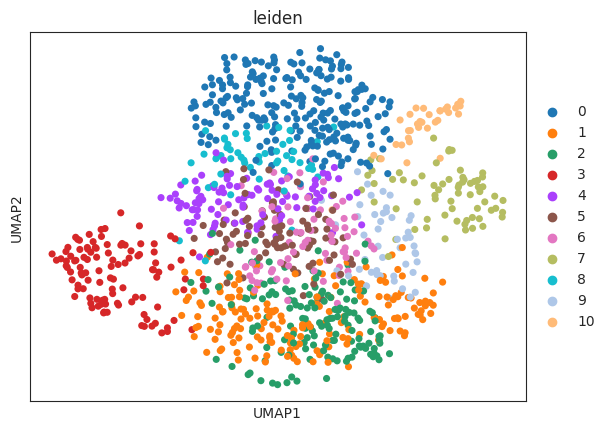

In [27]:
sc.pl.umap(adata, color=['leiden'])

In [28]:
# Get gene coordinates
df_annotations = gr_annotations.df.set_index('ensembl_gene_id')
df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})
adata.var_names = adata.var['ensembl_gene_id'].values
adata = adata[:,df_exp_annotations['ensembl_gene_id']]

In [29]:
print(adata)

View of AnnData object with n_obs × n_vars = 1146 × 2252
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


/home/andress/miniconda3/envs/scicone_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:646: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


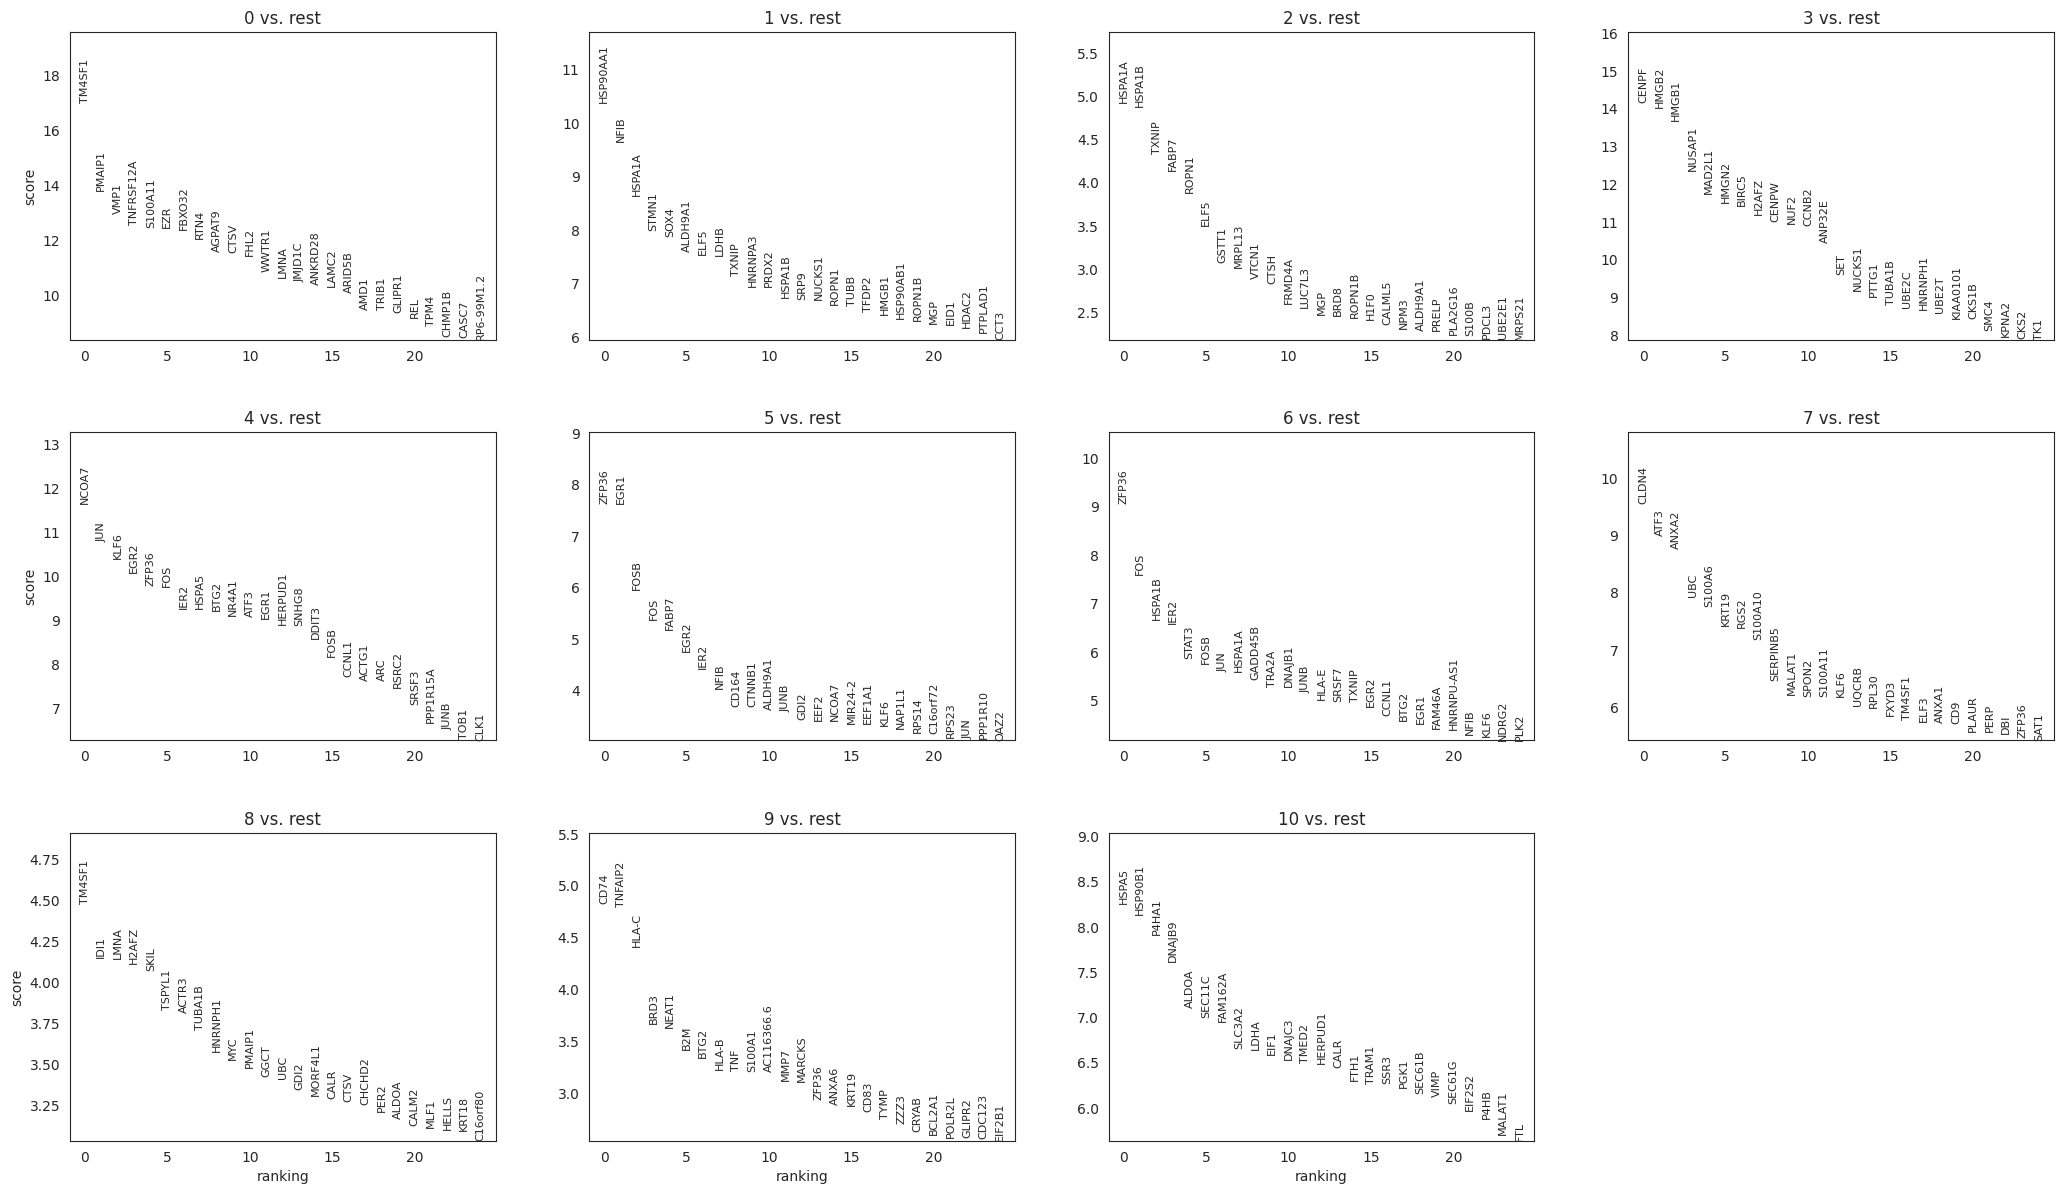

In [55]:
# Performing differential expression tests between the clones will reveal their phenotypic differences
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [56]:
# Using gseapy to annotate clusters according to their top DEGs
groups_genes = pd.DataFrame(adata.uns['rank_genes_groups']['names'])[:50].to_dict(orient='list')
import gseapy as gp
enrichments = []
for group in groups_genes:
    enr = []
    if len(groups_genes[group]) > 0:
        print(group)
        try:
          enr = gp.enrichr(gene_list=groups_genes[group],
                      gene_sets=['MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'Reactome_2016', 'GO_Biological_Process_2018'],
                      organism='Human',
                      outdir='test/enrichr',
                      cutoff=0.05
                      ).results
          enr = enr[['Term','Adjusted P-value']].set_index('Term')
          enr = enr.loc[enr['Adjusted P-value'] < 0.01]
          enr = enr.drop('Adjusted P-value', axis=1).index.values
        except ValueError as e:
          print(e)
    enrichments.append(enr)
enrichments = dict(zip([group for group in groups_genes], enrichments))
cluster_annotations = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in enrichments.items() ]))

0
1
2
3
4
5
6
7
8
9
10


In [57]:
cluster_annotations.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,TNF-alpha Signaling via NF-kB,Myc Targets V1,NaN,G2-M Checkpoint,TNF-alpha Signaling via NF-kB,TNF-alpha Signaling via NF-kB,TNF-alpha Signaling via NF-kB,NaN,mTORC1 Signaling,TNF-alpha Signaling via NF-kB,mTORC1 Signaling
1,Epithelial Mesenchymal Transition,Antigen processing and presentation,NaN,E2F Targets,Hypoxia,Myc Targets V1,UV Response Up,NaN,Myc Targets V1,Interferon Gamma Response,Unfolded Protein Response
2,UV Response Dn,Protein processing in endoplasmic reticulum,NaN,Mitotic Spindle,UV Response Up,Coronavirus disease,Apoptosis,NaN,positive regulation of cell aging (GO:0090343),UV Response Up,Hypoxia
3,Apoptosis,Estrogen signaling pathway,NaN,Myc Targets V1,p53 Pathway,Ribosome,p53 Pathway,NaN,protein-DNA complex disassembly (GO:0032986),IL-2/STAT5 Signaling,Glycolysis
4,Cholesterol Homeostasis,Spliceosome,NaN,Oocyte meiosis,Apoptosis,Amphetamine addiction,Hypoxia,NaN,NaN,p53 Pathway,p53 Pathway
5,Estrogen Response Early,Longevity regulating pathway,NaN,Cell cycle,Unfolded Protein Response,Human T-cell leukemia virus 1 infection,IL-6/JAK/STAT3 Signaling,NaN,NaN,Interferon Alpha Response,Protein processing in endoplasmic reticulum
6,Apoptosis,Lipid and atherosclerosis,NaN,Progesterone-mediated oocyte maturation,mTORC1 Signaling,Osteoclast differentiation,Epithelial Mesenchymal Transition,NaN,NaN,Androgen Response,Protein export
7,Small cell lung cancer,Legionellosis,NaN,p53 signaling pathway,Cholesterol Homeostasis,Eukaryotic Translation Elongation Homo sapiens...,Spliceosome,NaN,NaN,Human T-cell leukemia virus 1 infection,Glycolysis / Gluconeogenesis
8,PI3K-Akt signaling pathway,Prion disease,NaN,Cellular senescence,IL-6/JAK/STAT3 Signaling,Peptide chain elongation Homo sapiens R-HSA-15...,Human T-cell leukemia virus 1 infection,NaN,NaN,Antigen processing and presentation,HIF-1 signaling pathway
9,regulation of apoptotic process (GO:0042981),Attenuation phase Homo sapiens R-HSA-3371568,NaN,Human T-cell leukemia virus 1 infection,Amphetamine addiction,Translation Homo sapiens R-HSA-72766,Measles,NaN,NaN,Allograft rejection,Ferroptosis


In [61]:
# Inspect the adata variable
print(type(adata))
print(adata.shape)
print(adata)

<class 'anndata._core.anndata.AnnData'>
(1146, 2252)
AnnData object with n_obs × n_vars = 1146 × 2252
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'ensembl_gene_id', 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [62]:
# Create cells by regions matrix
import numpy as np
import pandas as pd

# Assuming gr_annotations contains the gene to region mapping
gene_to_region = gr_annotations.df[['ensembl_gene_id', 'Chromosome', 'Start', 'End']]
gene_to_region = gene_to_region.set_index('ensembl_gene_id')

# Map genes to regions in adata
adata.var = adata.var.join(gene_to_region, on='ensembl_gene_id')

# Group by regions and sum counts
regions = adata.var.groupby(['Chromosome', 'Start', 'End']).apply(lambda x: x.index.tolist())
cells_by_regions = pd.DataFrame(index=adata.obs_names)

for region, genes in regions.items():
    region_name = f'{region[0]}:{region[1]}-{region[2]}'
    cells_by_regions[region_name] = adata[:, genes].X.sum(axis=1)

print(cells_by_regions.shape)
cells_by_regions.head()

/tmp/ipykernel_34054/1224903390.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regions = adata.var.groupby(['Chromosome', 'Start', 'End']).apply(lambda x: x.index.tolist())
/tmp/ipykernel_34054/1224903390.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regions = adata.var.groupby(['Chromosome', 'Start', 'End']).apply(lambda x: x.index.tolist())
/tmp/ipykernel_34054/1224903390.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

(1146, 2252)


,1:764723-774280,1:778739-810066,1:1399476-1402054,1:1512162-1534685,1:1702379-1724357,1:2184461-2212720,1:3630767-3652761,1:3778559-3796498,1:6412418-6424670,1:6521347-6554513,...,X:136532215-136556807,X:149527591-149540959,X:150766336-150898816,X:150980509-150990771,X:152830967-152869729,X:153494980-153509546,X:153669733-153689010,X:153724856-153744755,X:154010506-154019902,X:154487306-154490690
AAACCTGAGATCCGAG-1,-0.082741,-0.181033,-0.185472,-0.178192,-0.314193,-0.259274,-0.271825,-0.187157,10.000000,-0.199487,...,-0.274176,-0.120428,-0.121643,1.022448,-0.309497,-0.095035,-0.205780,-0.137605,-0.200549,-0.140118
AAACCTGAGATGCCAG-1,0.003341,-0.142233,-0.214903,-0.049127,1.805603,-0.187023,-0.424045,-0.102142,-0.021718,-0.154950,...,-0.290219,-0.027480,-0.080313,-0.881784,-0.152630,-0.149698,-0.100092,-0.059782,-0.222541,-0.109299
AAACGGGTCCGTTGCT-1,-0.122274,-0.190690,-0.145870,-0.187765,-0.336749,-0.280588,-0.242181,-0.201681,-0.132835,-0.227523,...,-0.270957,-0.132744,-0.144613,-0.882748,-0.300703,-0.075935,-0.140800,-0.108957,-0.225898,-0.156447
AAAGATGAGGGCTTGA-1,-0.125452,-0.186465,-0.126702,-0.158081,-0.353637,-0.275030,-0.264470,-0.187824,-0.134274,-0.234422,...,-0.273241,-0.115125,-0.148904,-0.917084,-0.250464,-0.078079,-0.066019,-0.067200,4.685103,-0.159092
AAAGATGGTACTCGCG-1,-0.046906,-0.157867,-0.175306,-0.081754,-0.337188,-0.218999,-0.369793,-0.130695,-0.065222,-0.187463,...,2.411896,-0.055636,-0.107867,-0.905771,-0.174728,-0.122951,-0.064230,-0.049875,-0.240168,-0.129158
